# Particle Swarm Optimization (PSO)

### What is Particle Swarm Optimization?

Particle Swarm Optimization (PSO) is a **population-based stochastic optimization algorithm** inspired by the social behavior of birds flocking or fish schooling. It was developed by Kennedy and Eberhart in 1995.

#### 🐦 The Analogy:
Think of a flock of birds searching for food:
* **Each bird** = a **particle** (potential solution)
* **The food** = **global optimum** (best solution)
* Birds share information about where they found food.
* The flock gradually converges to the best food source.

## Part 1: Mathematical Foundation

### 1.1 Particle Information

Each particle $i$ in the swarm maintains:
* **$x_i$**: Current position (potential solution)
* **$v_i$**: Current velocity (direction and speed of movement)
* **$p_i$**: Personal best position (best solution found by this particle)
* **$g_{best}$**: Global best position (best solution found by the entire swarm)

### 1.2 Personal Best Update Rule

The personal best position ($p_i$) for each particle is updated by comparing the fitness of its new position against the fitness of its previous best position:

$$p_i(t+1) = \begin{cases} 
p_i(t) & \text{if } f(x_i(t+1)) \ge f(p_i(t)) \\ 
x_i(t+1) & \text{if } f(x_i(t+1)) < f(p_i(t)) 
\end{cases}$$

**Where:**
* $t$ = current time step (iteration)
* $f(x)$ = the fitness function (the objective function being minimized)
* $x_i(t+1)$ = the particle's newly calculated position
* $p_i(t)$ = the particle's historical best position


### 1.3 Global Best Selection 
$$g_{best} = \min\{f(p_0(t)), f(p_1(t)), \dots, f(p_m(t))\}$$

*The global best is the best among all particles' personal bests.*

---

### 1.4 Velocity Update 
$$v_i(t+1) = w \cdot v_i(t) + c_1 \cdot r_1 \cdot (p_i - x_i) + c_2 \cdot r_2 \cdot (g_{best} - x_i)$$

**Where:**
* $w$: Inertia weight (controls exploration vs exploitation)
* $c_1, c_2$: Acceleration constants (cognitive and social components)
* $r_1, r_2$: Random numbers in [0,1]
* $p_i - x_i$: Cognitive component (particle's own experience)
* $g_{best} - x_i$: Social component (swarm's collective knowledge)

---

### 1.5 Position Update 
$$x_i(t+1) = x_i(t) + v_i(t+1)$$


## Part 2: Algorithm Steps (From Flowchart)



### Algorithmic Pseudo-code

1. **START:** Initialize particles with random positions $x_i$ and velocities $v_i$.
2. **WHILE** stopping criteria is not met **DO**:
    * **For** each particle $i$:
        * Evaluate fitness $f(x_i)$
        * **If** $f(x_i) < f(p_i)$ **then**: 
            * Update personal best: $p_i = x_i$
    * **Update global best:** $g_{best} = \min(f(p_0), f(p_1), \dots, f(p_m))$
    * **For** each particle $i$:
        * Update velocity using Equation 18: $v_i(t+1)$
        * Update position using Equation 19: $x_i(t+1)$
3. **STOP:** Return $g_{best}$ as the optimal solution.

## Part 2: Algorithm Steps (From Flowchart)

### Algorithmic Pseudo-code

1. **START:** Initialize particles with random positions $x_i$ and velocities $v_i$.
2. **WHILE** stopping criteria is not met **DO**:
    * **For** each particle $i$:
        * Evaluate fitness $f(x_i)$
        * **If** $f(x_i) < f(p_i)$ **then**:
            * Update personal best: $p_i = x_i$
    * **Update global best:** $g_{best} = \min(f(p_0), f(p_1), \dots, f(p_m))$
    * **For** each particle $i$:
        * Update velocity using Equation 18: $v_i(t+1)$
        * Update position using Equation 19: $x_i(t+1)$
3. **STOP:** Return $g_{best}$ as the optimal solution.

---

### Visual Flowchart

```text
  [START]
     │
     ▼
  Initialize particles (random xᵢ, vᵢ)
     │
     ▼
┌──► [LOOP] until stopping criteria met
│    │
│    ├─► For each particle:
│    │    │
│    │    ├─► Evaluate fitness f(xᵢ)
│    │    │
│    │    ├─► If f(xᵢ) < f(pᵢ) ──► pᵢ = xᵢ
│    │    │
│    │    └─► Update global best: g_best = min(all pᵢ)
│    │
│    ├─► For each particle:
│    │    │
│    │    ├─► Update velocity using Eq (18)
│    │    │
│    │    └─► Update position using Eq (19)
│    │
│    └─► Check stopping criteria (max iterations or convergence)
│         │
└─────────┘ (If not met, repeat loop)
     │
     ▼ (If met)
  [STOP] Return g_best as optimal solution



## Part 3: Stopping Criteria and Parameter Tuning

### 3.1 Stopping Criteria
The algorithm needs a condition to break the loop and return the final $g_{best}$. Common stopping criteria include:

* **Maximum Iterations ($t_{max}$):** The loop runs for a pre-defined number of iterations.
* **Target Fitness Achieved:** The algorithm stops if $g_{best}$ reaches an acceptable, pre-defined error threshold or target value.
* **Stagnation (No Improvement):** The loop terminates if $g_{best}$ does not improve by a minimum tolerance ($\epsilon$) over a set number of consecutive iterations.

---

### 3.2 Tuning the Inertia Weight ($w$)
The inertia weight controls the trade-off between **exploration** (searching new areas) and **exploitation** (refining known good areas). 

Instead of keeping $w$ constant, a common and highly effective strategy is to **linearly decrease** it over time. This allows the swarm to explore widely at the beginning and fine-tune its position near the end:

$$w(t) = w_{max} - \left( \frac{w_{max} - w_{min}}{t_{max}} \right) t$$

**Typical Values:**
* $w_{max} \approx 0.9$ (Starts with high exploration)
* $w_{min} \approx 0.4$ (Ends with high exploitation)
* $t$ = current iteration
* $t_{max}$ = maximum number of iterations

---

### 3.3 Tuning the Acceleration Constants ($c_1, c_2$)
These constants dictate how strongly the particle is pulled toward its own memory versus the swarm's collective memory.

* **$c_1$ (Cognitive Parameter):** Pulls the particle toward its personal best ($p_i$).
* **$c_2$ (Social Parameter):** Pulls the particle toward the global best ($g_{best}$).

**Standard Practice:**
Usually, both are set to exactly **2.0**, giving equal weight to personal experience and swarm knowledge. 
* If $c_1 > c_2$: The swarm explores more but converges slower (particles are stubborn).
* If $c_2 > c_1$: The swarm converges faster but risks getting trapped in local minima (particles are followers).

### PSO Parameters and Their Effects

| Parameter | Symbol | Range | Effect |
| :--- | :--- | :--- | :--- |
| **Inertia Weight** | $w$ | 0.3 - 0.9 | Controls exploration vs exploitation |
| **Cognitive Constant** | $c_1$ | 1 - 2 | Pull towards personal best |
| **Social Constant** | $c_2$ | 1 - 2 | Pull towards global best |
| **Swarm Size** | $N$ | 20 - 50 | More particles = better exploration |

🐦 PARTICLE SWARM OPTIMIZATION FOR IMAGE COMPRESSION

📚 Using PSO to find optimal color palette
   Each particle = a color palette
   Fitness = MSE between original and reconstructed image
   K-Means implementation uses custom code (no sklearn needed)
✅ Loaded: Lenna.png

🖼️  PSO IMAGE COMPRESSION DEMONSTRATION

🔍 Step 1: Testing different color counts...
   Testing K=4...

🔷 PSO Image Compression (K=4 colors)
   Image: 256×256, 65,536 pixels
   Particles: 20, Max iterations: 30

✅ Optimization complete in 3.03s
   Best MSE: 420.5754
   Compression ratio: 11.991:1
   Testing K=8...

🔷 PSO Image Compression (K=8 colors)
   Image: 256×256, 65,536 pixels
   Particles: 20, Max iterations: 30

✅ Optimization complete in 5.16s
   Best MSE: 190.7432
   Compression ratio: 7.992:1
   Testing K=16...

🔷 PSO Image Compression (K=16 colors)
   Image: 256×256, 65,536 pixels
   Particles: 20, Max iterations: 30

✅ Optimization complete in 10.29s
   Best MSE: 186.7472
   Compression ratio: 5.991:1
   

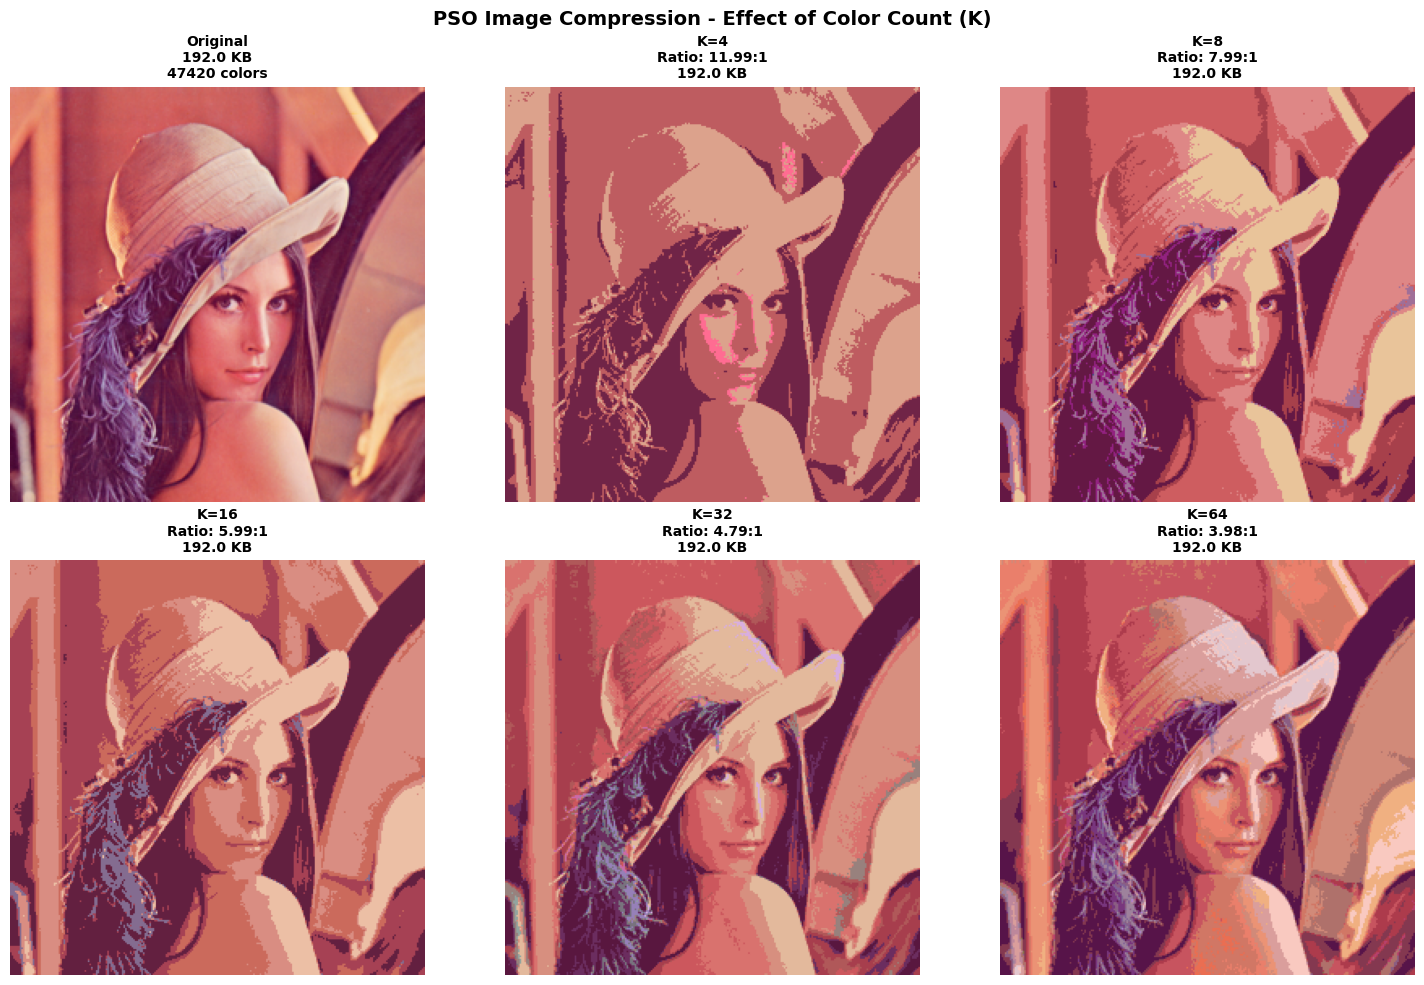


🔍 Step 2: PSO Compression with K=16...

🔷 PSO Image Compression (K=16 colors)
   Image: 256×256, 65,536 pixels
   Particles: 30, Max iterations: 50
   Iter   0: Best MSE = 585.4935
   Iter  10: Best MSE = 230.1958
   Iter  20: Best MSE = 166.2174
   Iter  30: Best MSE = 152.8194
   Iter  40: Best MSE = 135.3235
   Iter  49: Best MSE = 126.7974

✅ Optimization complete in 24.84s
   Best MSE: 126.7974
   Compression ratio: 5.991:1

🔍 Step 3: Generating visualizations...


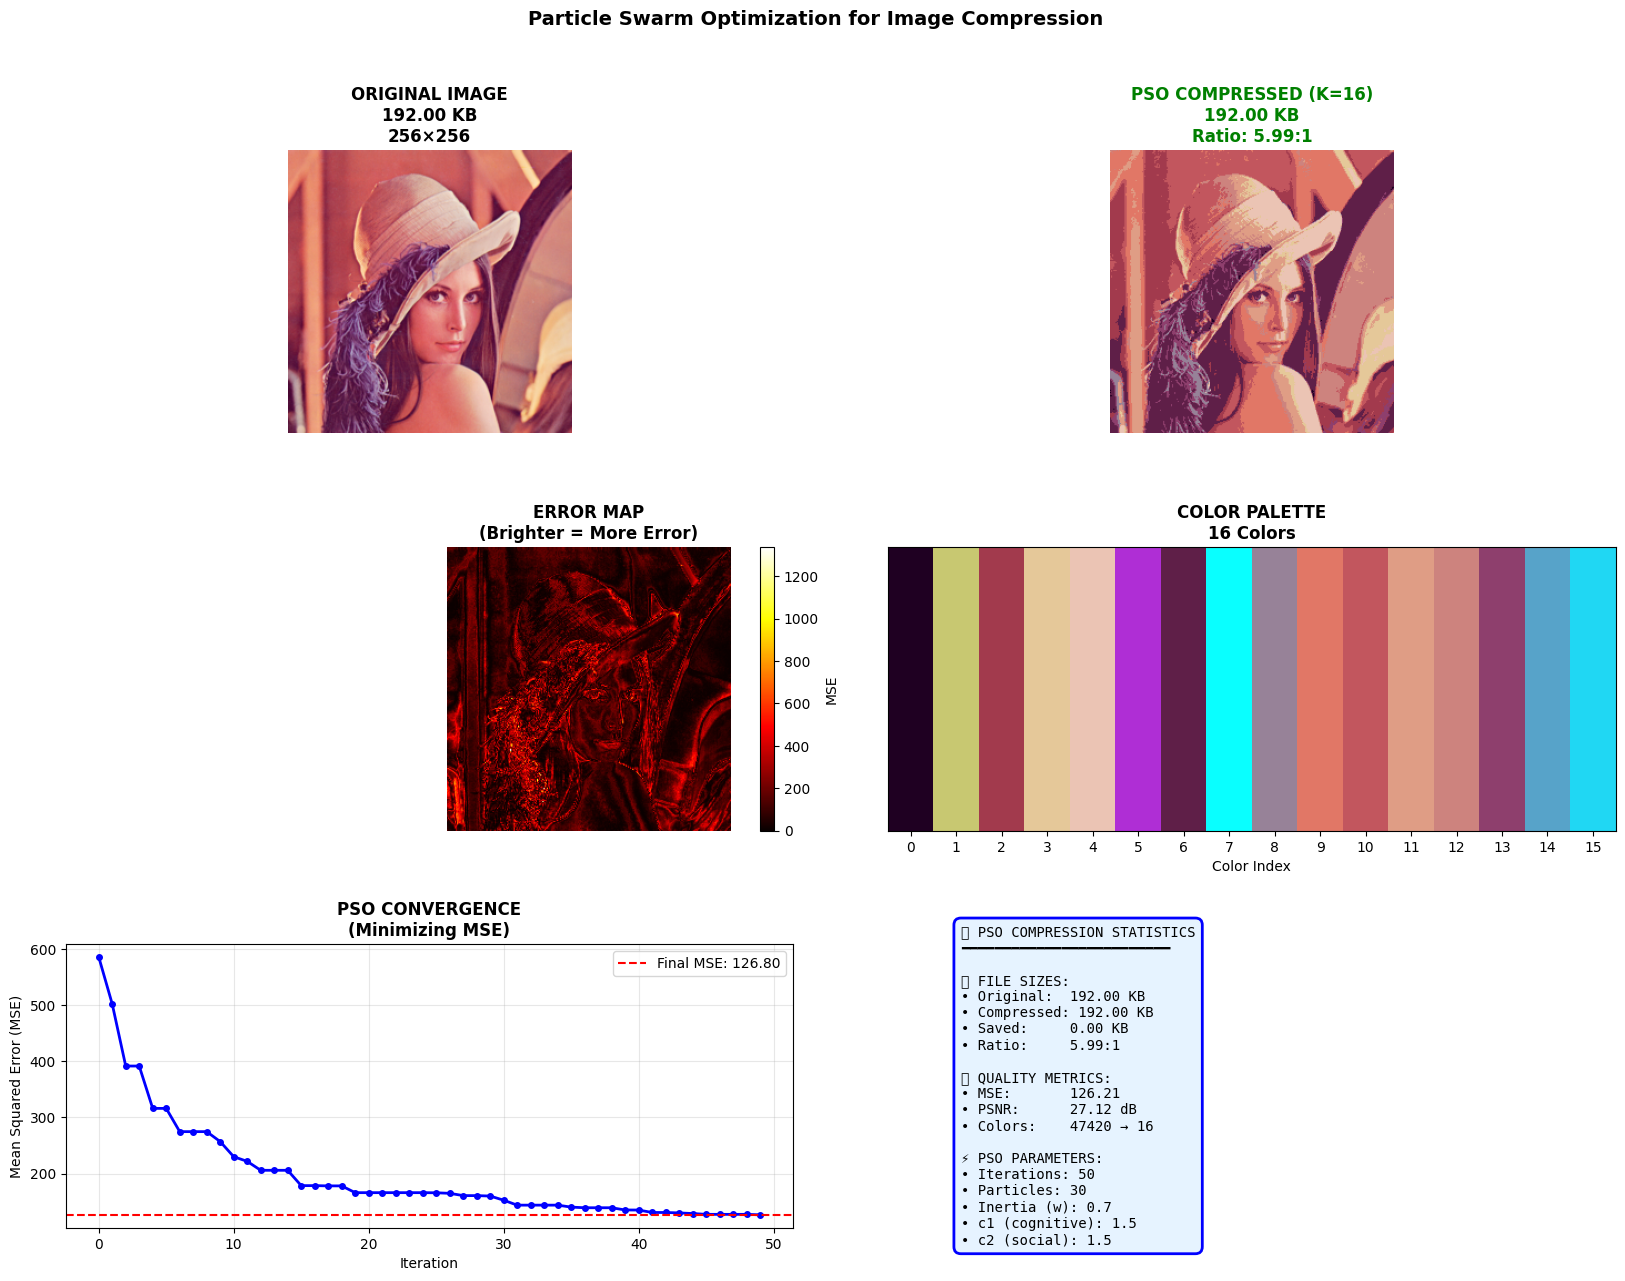


🔍 Step 4: Comparing with K-Means...


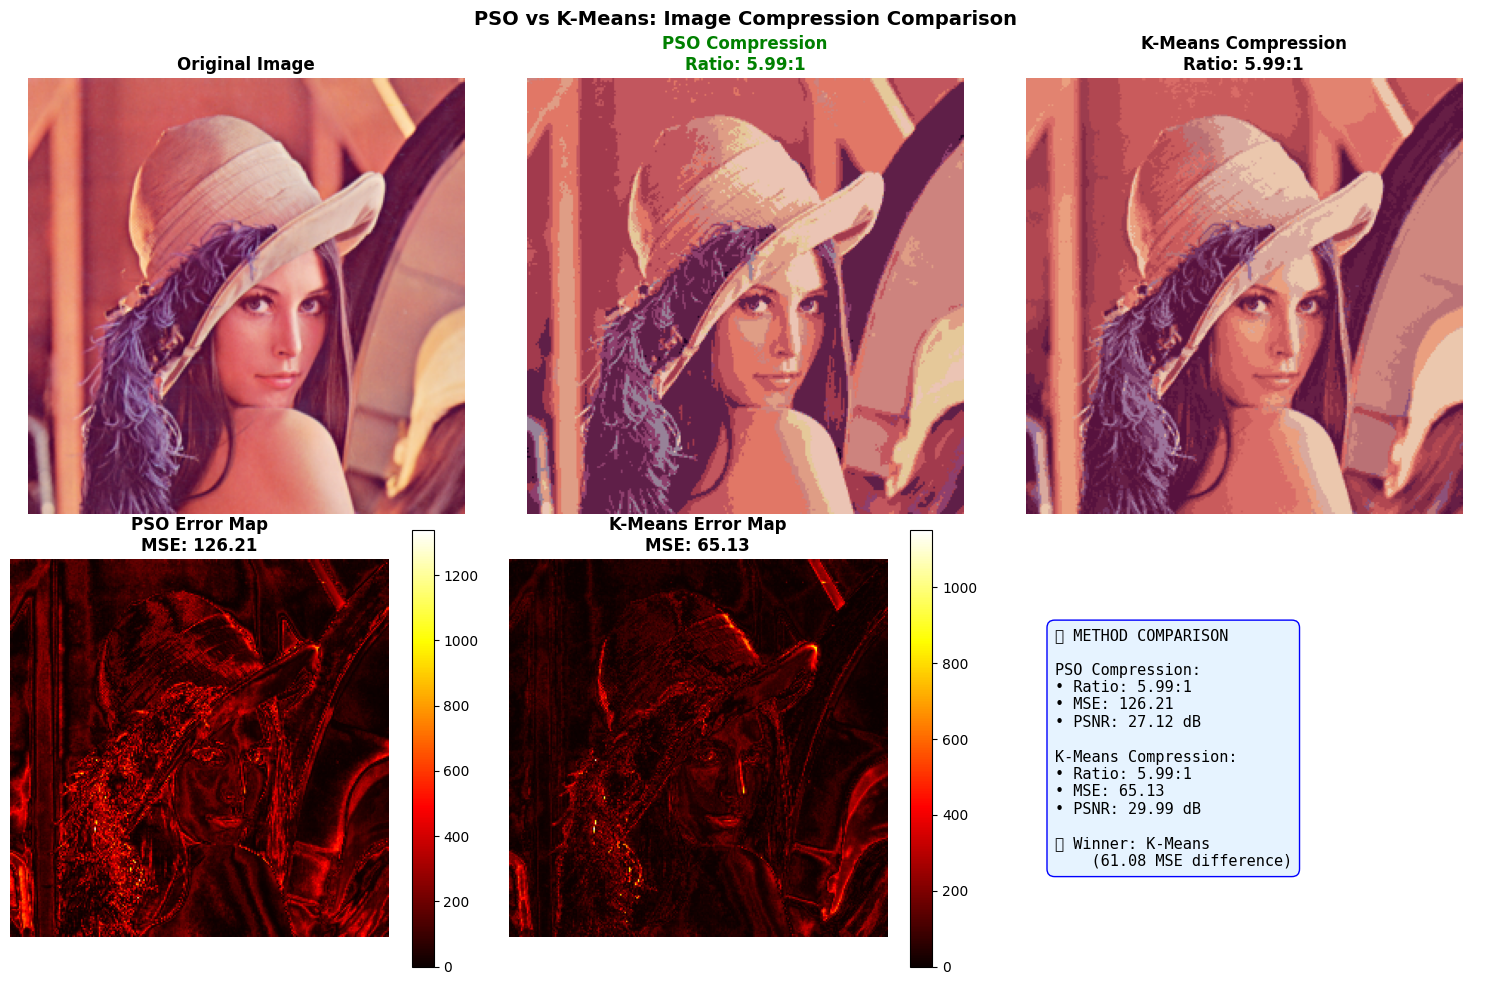

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import time
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PSO-BASED IMAGE COMPRESSION (NO SKLEARN DEPENDENCY)
# ============================================================================

class PSOImageCompression:
    """
    Particle Swarm Optimization for Image Color Quantization
    
    Uses PSO to find optimal color palette for image compression
    """
    
    def __init__(self, n_colors=16, n_particles=30, max_iter=50, 
                 w=0.7, c1=1.5, c2=1.5, verbose=True):
        
        self.n_colors = n_colors      # Number of colors in palette (K)
        self.n_particles = n_particles
        self.max_iter = max_iter
        self.w = w
        self.c1 = c1
        self.c2 = c2
        self.verbose = verbose
        
        # PSO storage
        self.positions = None          # Particle positions (color palettes)
        self.velocities = None         # Particle velocities
        self.personal_best_pos = None   # Personal best palettes
        self.personal_best_fitness = None
        self.global_best_pos = None     # Global best palette
        self.global_best_fitness = float('inf')
        
        # History for visualization
        self.fitness_history = []
        self.best_palette_history = []
        
        # Results
        self.best_palette = None
        self.compressed_image = None
        self.compression_ratio = None
        
    def initialize_particles(self, image_pixels):
        """Initialize particles with random color palettes"""
        n_pixels, n_channels = image_pixels.shape
        
        # Each particle is a color palette (n_colors x 3)
        palette_size = self.n_colors * 3
        
        # Random positions within [0, 255]
        self.positions = np.random.uniform(0, 255, 
                                          (self.n_particles, palette_size))
        
        # Velocities (10% of range)
        self.velocities = np.random.uniform(-25.5, 25.5, 
                                           (self.n_particles, palette_size))
        
        # Personal bests
        self.personal_best_pos = self.positions.copy()
        self.personal_best_fitness = np.full(self.n_particles, float('inf'))
        
    def palette_to_image(self, palette, pixels):
        """Convert palette to compressed image"""
        # Reshape palette to (n_colors, 3)
        palette_reshaped = palette.reshape(self.n_colors, 3)
        
        # Find closest color for each pixel
        distances = np.linalg.norm(pixels[:, np.newaxis, :] - palette_reshaped, axis=2)
        labels = np.argmin(distances, axis=1)
        
        # Reconstruct image
        reconstructed = palette_reshaped[labels]
        
        return reconstructed, labels
    
    def evaluate_fitness(self, palette, original_pixels):
        """
        Fitness function: MSE between original and compressed image
        Lower MSE = better fitness
        """
        reconstructed, _ = self.palette_to_image(palette, original_pixels)
        mse = np.mean((original_pixels - reconstructed) ** 2)
        return mse
    
    def update_velocity(self):
        """Update particle velocities using PSO equation (18)"""
        r1 = np.random.random(self.positions.shape)
        r2 = np.random.random(self.positions.shape)
        
        # Cognitive component
        cognitive = self.c1 * r1 * (self.personal_best_pos - self.positions)
        
        # Social component
        social = self.c2 * r2 * (self.global_best_pos - self.positions)
        
        # Velocity update
        self.velocities = self.w * self.velocities + cognitive + social
        
        # Velocity clamping
        max_vel = 50
        self.velocities = np.clip(self.velocities, -max_vel, max_vel)
    
    def update_position(self):
        """Update particle positions using equation (19)"""
        self.positions = self.positions + self.velocities
        
        # Boundary clamping
        self.positions = np.clip(self.positions, 0, 255)
    
    def compress(self, image_array):
        """
        Compress image using PSO-optimized color quantization
        
        Args:
            image_array: RGB image of shape (height, width, 3)
            
        Returns:
            compressed: compressed image
            ratio: compression ratio
            palette: optimal color palette
        """
        h, w, c = image_array.shape
        pixels = image_array.reshape(-1, c).astype(np.float32)
        
        print(f"\n🔷 PSO Image Compression (K={self.n_colors} colors)")
        print(f"   Image: {h}×{w}, {pixels.shape[0]:,} pixels")
        print(f"   Particles: {self.n_particles}, Max iterations: {self.max_iter}")
        
        # Initialize particles
        self.initialize_particles(pixels)
        
        # Main PSO loop
        start_time = time.time()
        
        for iteration in range(self.max_iter):
            # Evaluate fitness for all particles
            for i in range(self.n_particles):
                fitness = self.evaluate_fitness(self.positions[i], pixels)
                
                # Update personal best
                if fitness < self.personal_best_fitness[i]:
                    self.personal_best_fitness[i] = fitness
                    self.personal_best_pos[i] = self.positions[i].copy()
                
                # Update global best
                if fitness < self.global_best_fitness:
                    self.global_best_fitness = fitness
                    self.global_best_pos = self.positions[i].copy()
            
            # Store history
            self.fitness_history.append(self.global_best_fitness)
            self.best_palette_history.append(self.global_best_pos.copy())
            
            # Update velocities and positions
            self.update_velocity()
            self.update_position()
            
            if self.verbose and (iteration % 10 == 0 or iteration == self.max_iter-1):
                print(f"   Iter {iteration:3d}: Best MSE = {self.global_best_fitness:.4f}")
        
        elapsed = time.time() - start_time
        
        # Get best palette
        self.best_palette = self.global_best_pos.reshape(self.n_colors, 3).astype(np.uint8)
        
        # Compress image with best palette
        reconstructed, labels = self.palette_to_image(self.global_best_pos, pixels)
        self.compressed_image = reconstructed.reshape(h, w, c).astype(np.uint8)
        
        # Calculate compression ratio
        original_bits = h * w * c * 8
        palette_bits = self.n_colors * c * 8
        index_bits = h * w * np.ceil(np.log2(self.n_colors))
        compressed_bits = palette_bits + index_bits
        self.compression_ratio = original_bits / compressed_bits
        
        print(f"\n✅ Optimization complete in {elapsed:.2f}s")
        print(f"   Best MSE: {self.global_best_fitness:.4f}")
        print(f"   Compression ratio: {self.compression_ratio:.3f}:1")
        
        return self.compressed_image, self.compression_ratio, self.best_palette, labels.reshape(h, w)


# ============================================================================
# SIMPLE K-MEANS IMPLEMENTATION (NO SKLEARN DEPENDENCY)
# ============================================================================

class SimpleKMeans:
    """
    Simple K-Means implementation for color quantization
    """
    
    def __init__(self, n_clusters=16, max_iters=100):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.centers = None
        self.labels = None
        
    def fit(self, X):
        """Fit K-Means to data"""
        np.random.seed(42)
        
        # Initialize centers randomly
        indices = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centers = X[indices].copy()
        
        for iteration in range(self.max_iters):
            # Assign labels
            distances = np.linalg.norm(X[:, np.newaxis, :] - self.centers, axis=2)
            self.labels = np.argmin(distances, axis=1)
            
            # Update centers
            new_centers = np.zeros_like(self.centers)
            for i in range(self.n_clusters):
                if np.sum(self.labels == i) > 0:
                    new_centers[i] = np.mean(X[self.labels == i], axis=0)
                else:
                    new_centers[i] = self.centers[i]
            
            # Check convergence
            if np.allclose(self.centers, new_centers):
                break
                
            self.centers = new_centers
        
        return self
    
    def predict(self, X):
        """Predict cluster labels"""
        distances = np.linalg.norm(X[:, np.newaxis, :] - self.centers, axis=2)
        return np.argmin(distances, axis=1)


# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def visualize_pso_compression(original, compressed, palette, labels, ratio, fitness_history, n_colors):
    """Comprehensive visualization of PSO compression results"""
    
    h, w, c = original.shape
    original_kb = original.nbytes / 1024
    compressed_kb = compressed.nbytes / 1024
    
    fig = plt.figure(figsize=(20, 14))
    gs = GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.3)
    
    # ===== ROW 1: Original vs Compressed =====
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax1.imshow(original)
    ax1.set_title(f'ORIGINAL IMAGE\n{original_kb:.2f} KB\n{h}×{w}', 
                  fontsize=12, fontweight='bold')
    ax1.axis('off')
    
    ax2 = fig.add_subplot(gs[0, 2:4])
    ax2.imshow(compressed)
    ax2.set_title(f'PSO COMPRESSED (K={n_colors})\n{compressed_kb:.2f} KB\nRatio: {ratio:.2f}:1', 
                  fontsize=12, fontweight='bold', color='green')
    ax2.axis('off')
    
    # ===== ROW 2: Error Map and Color Palette =====
    ax3 = fig.add_subplot(gs[1, 0:2])
    diff = np.mean((original.astype(float) - compressed.astype(float))**2, axis=2)
    im3 = ax3.imshow(diff, cmap='hot')
    ax3.set_title('ERROR MAP\n(Brighter = More Error)', fontsize=12, fontweight='bold')
    ax3.axis('off')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04, label='MSE')
    
    ax4 = fig.add_subplot(gs[1, 2:4])
    # Display color palette
    palette_img = palette.reshape(1, -1, 3).repeat(50, axis=0)
    ax4.imshow(palette_img, aspect='auto')
    ax4.set_title(f'COLOR PALETTE\n{n_colors} Colors', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Color Index')
    ax4.set_xticks(range(n_colors))
    ax4.set_xticklabels(range(n_colors))
    ax4.set_yticks([])
    
    # ===== ROW 3: Convergence and Statistics =====
    ax5 = fig.add_subplot(gs[2, 0:2])
    ax5.plot(fitness_history, 'b-', linewidth=2, marker='o', markersize=4)
    ax5.set_title('PSO CONVERGENCE\n(Minimizing MSE)', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Iteration')
    ax5.set_ylabel('Mean Squared Error (MSE)')
    ax5.grid(True, alpha=0.3)
    ax5.axhline(y=fitness_history[-1], color='r', linestyle='--', 
                label=f'Final MSE: {fitness_history[-1]:.2f}')
    ax5.legend()
    
    ax6 = fig.add_subplot(gs[2, 2:4])
    ax6.axis('off')
    
    mse = np.mean((original.astype(float) - compressed.astype(float))**2)
    psnr = 20 * np.log10(255.0 / np.sqrt(mse)) if mse > 0 else float('inf')
    
    stats = f"""📊 PSO COMPRESSION STATISTICS
━━━━━━━━━━━━━━━━━━━━━━━━━

📦 FILE SIZES:
• Original:  {original_kb:.2f} KB
• Compressed: {compressed_kb:.2f} KB
• Saved:     {original_kb - compressed_kb:.2f} KB
• Ratio:     {ratio:.2f}:1

🎯 QUALITY METRICS:
• MSE:       {mse:.2f}
• PSNR:      {psnr:.2f} dB
• Colors:    {len(np.unique(original.reshape(-1,3), axis=0))} → {n_colors}

⚡ PSO PARAMETERS:
• Iterations: {len(fitness_history)}
• Particles: 30
• Inertia (w): 0.7
• c1 (cognitive): 1.5
• c2 (social): 1.5"""
    
    ax6.text(0.1, 0.5, stats, fontsize=10, fontfamily='monospace', va='center',
            bbox=dict(boxstyle="round,pad=0.5", facecolor='#e6f3ff', edgecolor='blue', linewidth=2))
    
    plt.suptitle(f'Particle Swarm Optimization for Image Compression', 
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()


def compare_compression_methods(original, pso_compressed, kmeans_compressed, pso_ratio, kmeans_ratio):
    """Compare PSO compression with K-Means compression"""
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Original
    axes[0, 0].imshow(original)
    axes[0, 0].set_title('Original Image', fontweight='bold')
    axes[0, 0].axis('off')
    
    # PSO Compressed
    axes[0, 1].imshow(pso_compressed)
    axes[0, 1].set_title(f'PSO Compression\nRatio: {pso_ratio:.2f}:1', fontweight='bold', color='green')
    axes[0, 1].axis('off')
    
    # K-Means Compressed
    axes[0, 2].imshow(kmeans_compressed)
    axes[0, 2].set_title(f'K-Means Compression\nRatio: {kmeans_ratio:.2f}:1', fontweight='bold')
    axes[0, 2].axis('off')
    
    # PSO Error
    pso_error = np.mean((original.astype(float) - pso_compressed.astype(float))**2, axis=2)
    im1 = axes[1, 0].imshow(pso_error, cmap='hot')
    axes[1, 0].set_title(f'PSO Error Map\nMSE: {pso_error.mean():.2f}', fontweight='bold')
    axes[1, 0].axis('off')
    plt.colorbar(im1, ax=axes[1, 0])
    
    # K-Means Error
    kmeans_error = np.mean((original.astype(float) - kmeans_compressed.astype(float))**2, axis=2)
    im2 = axes[1, 1].imshow(kmeans_error, cmap='hot')
    axes[1, 1].set_title(f'K-Means Error Map\nMSE: {kmeans_error.mean():.2f}', fontweight='bold')
    axes[1, 1].axis('off')
    plt.colorbar(im2, ax=axes[1, 1])
    
    # Comparison Text
    axes[1, 2].axis('off')
    pso_mse = pso_error.mean()
    kmeans_mse = kmeans_error.mean()
    
    comparison = f"""📊 METHOD COMPARISON

PSO Compression:
• Ratio: {pso_ratio:.2f}:1
• MSE: {pso_mse:.2f}
• PSNR: {20*np.log10(255/np.sqrt(pso_mse)):.2f} dB

K-Means Compression:
• Ratio: {kmeans_ratio:.2f}:1
• MSE: {kmeans_mse:.2f}
• PSNR: {20*np.log10(255/np.sqrt(kmeans_mse)):.2f} dB

🏆 Winner: {"PSO" if pso_mse < kmeans_mse else "K-Means"}
    ({abs(pso_mse - kmeans_mse):.2f} MSE difference)"""
    
    axes[1, 2].text(0.1, 0.5, comparison, fontsize=11, fontfamily='monospace', va='center',
                   bbox=dict(boxstyle="round,pad=0.5", facecolor='#e6f3ff', edgecolor='blue'))
    
    plt.suptitle('PSO vs K-Means: Image Compression Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def visualize_different_k_values(original):
    """Show compression results with different numbers of colors"""
    
    k_values = [4, 8, 16, 32, 64]
    
    # Create 2 rows, 3 columns grid (6 subplots)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    # Original
    axes[0].imshow(original)
    axes[0].set_title(f'Original\n{original.nbytes/1024:.1f} KB\n{len(np.unique(original.reshape(-1,3), axis=0))} colors', 
                      fontweight='bold', fontsize=10)
    axes[0].axis('off')
    
    # Test different K values (indices 1-5)
    for idx, k in enumerate(k_values):
        print(f"   Testing K={k}...")
        
        pso = PSOImageCompression(n_colors=k, n_particles=20, max_iter=30, verbose=False)
        compressed, ratio, palette, labels = pso.compress(original)
        
        axes[idx+1].imshow(compressed)
        axes[idx+1].set_title(f'K={k}\nRatio: {ratio:.2f}:1\n{compressed.nbytes/1024:.1f} KB', 
                              fontweight='bold', fontsize=10)
        axes[idx+1].axis('off')
    
    plt.suptitle('PSO Image Compression - Effect of Color Count (K)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================================================
# MAIN DEMONSTRATION
# ============================================================================

def demonstrate_pso_image_compression(image_path="Lenna.png"):
    """Complete PSO image compression demonstration"""
    
    # Load image
    if os.path.exists(image_path):
        img = Image.open(image_path).convert('RGB')
        img = img.resize((256, 256))
        original = np.array(img)
        print(f"✅ Loaded: {image_path}")
    else:
        print("⚠️ Creating synthetic test image")
        original = np.zeros((256, 256, 3), dtype=np.uint8)
        for i in range(256):
            original[i, :, 0] = i
            original[i, :, 1] = 255 - i
            original[i, :, 2] = 128
    
    print("\n" + "="*80)
    print("🖼️  PSO IMAGE COMPRESSION DEMONSTRATION")
    print("="*80)
    
    # Step 1: Show effect of different K values
    print("\n🔍 Step 1: Testing different color counts...")
    visualize_different_k_values(original)
    
    # Step 2: Compress with PSO (K=16)
    print("\n🔍 Step 2: PSO Compression with K=16...")
    pso = PSOImageCompression(n_colors=16, n_particles=30, max_iter=50, verbose=True)
    compressed, ratio, palette, labels = pso.compress(original)
    
    # Step 3: Visualize results
    print("\n🔍 Step 3: Generating visualizations...")
    visualize_pso_compression(original, compressed, palette, labels, ratio, 
                              pso.fitness_history, 16)
    
    # Step 4: Compare with K-Means (using custom implementation)
    print("\n🔍 Step 4: Comparing with K-Means...")
    
    # Use custom K-Means (no sklearn needed)
    pixels = original.reshape(-1, 3).astype(np.float32)
    km = SimpleKMeans(n_clusters=16, max_iters=100)
    km.fit(pixels)
    km_labels = km.predict(pixels)
    km_centers = km.centers.astype(np.uint8)
    km_compressed = km_centers[km_labels].reshape(256, 256, 3)
    
    original_bits = 256 * 256 * 3 * 8
    km_compressed_bits = 16 * 3 * 8 + 256 * 256 * 4
    km_ratio = original_bits / km_compressed_bits
    
    compare_compression_methods(original, compressed, km_compressed, ratio, km_ratio)
    
    return pso, compressed, ratio


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("="*80)
    print("🐦 PARTICLE SWARM OPTIMIZATION FOR IMAGE COMPRESSION")
    print("="*80)
    print("\n📚 Using PSO to find optimal color palette")
    print("   Each particle = a color palette")
    print("   Fitness = MSE between original and reconstructed image")
    print("   K-Means implementation uses custom code (no sklearn needed)")
    
    # Run demonstration
    pso, compressed, ratio = demonstrate_pso_image_compression("Lenna.png")